1. What is unsupervised learning in the context of machine learning?

Unsupervised learning is a type of machine learning where the model learns patterns from unlabeled data without knowing the correct output.

2. How does K-Means clustering algorithm work?
Choose the number of clusters (K).
Initialize K centroids.
Assign each data point to the nearest centroid.
Update centroids by taking the mean of assigned points.
Repeat until centroids no longer change significantly.

3. Explain the concept of a dendrogram in hierarchical clustering.

A dendrogram is a tree-like diagram that shows how clusters are merged or split at different distances. It helps determine the appropriate number of clusters

4. What is the main difference between K-Means and Hierarchical Clustering?

K-Means requires the number of clusters (K) to be specified beforehand, while Hierarchical Clustering does not. Hierarchical Clustering creates a tree structure (dendrogram), whereas K-Means partitions data into K clusters.

5. What are the advantages of DBSCAN over K-Means?
Does not require specifying the number of clusters.
Can detect clusters of arbitrary shapes.
Identifies noise and outliers.
More robust to outliers than K-Means.

6. When would you use Silhouette Score in clustering?

Silhouette Score is used to evaluate the quality of clustering and to help choose the optimal number of clusters.

7. What are the limitations of Hierarchical Clustering?
Computationally expensive for large datasets.
Sensitive to noise and outliers.
Once clusters are merged or split, they cannot be undone.

8. Why is feature scaling important in clustering algorithms like K-Means?

K-Means uses distance calculations. Without feature scaling, features with larger values dominate the clustering process, leading to inaccurate clusters.

9. How does DBSCAN identify noise points?

DBSCAN labels a point as noise if it does not have enough neighboring points within the specified radius (eps) to form a dense region.

10. Define inertia in the context of K-Means.

Inertia is the sum of squared distances between each data point and its assigned cluster centroid. Lower inertia indicates tighter clusters.

11. What is the elbow method in K-Means clustering?

The Elbow Method helps determine the optimal value of K by plotting inertia against different K values and selecting the point where the decrease in inertia starts to level off (the "elbow").

12. Describe the concept of "density" in DBSCAN.

Density refers to the number of data points within a specified radius (eps) around a point. Dense regions form clusters.

13. Can hierarchical clustering be used on categorical data?

Yes. Hierarchical clustering can be applied to categorical data using appropriate distance measures, such as Hamming distance.

14. What does a negative Silhouette Score indicate?

A negative Silhouette Score indicates that many data points are assigned to the wrong cluster and may belong to a neighboring cluster.

15. Explain the term "linkage criteria" in hierarchical clustering.

Linkage criteria determine how the distance between two clusters is calculated during clustering.

Common types include:

Single linkage
Complete linkage
Average linkage
Ward linkage

16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?

K-Means assumes clusters are similar in size and roughly spherical. It struggles with clusters that have different sizes, densities, or irregular shapes.

17. What are the core parameters in DBSCAN, and how do they influence clustering?

The two main parameters are:

eps (ε): Maximum distance between neighboring points.
min_samples: Minimum number of points required to form a dense region.

These parameters determine cluster formation and noise detection.

18. How does K-Means++ improve upon standard K-Means initialization?

K-Means++ selects initial centroids more strategically, spreading them apart. This leads to faster convergence and better clustering results.

19. What is agglomerative clustering?

Agglomerative clustering is a bottom-up hierarchical clustering method where each data point starts as its own cluster, and the closest clusters are merged repeatedly until one cluster or the desired number of clusters remains.

20. What makes Silhouette Score a better metric than just inertia for model evaluation?

Silhouette Score evaluates both cluster cohesion (how close points are within a cluster) and cluster separation (how distinct clusters are). Inertia only measures compactness and generally decreases as K increases, making it less reliable for selecting the best clustering model.

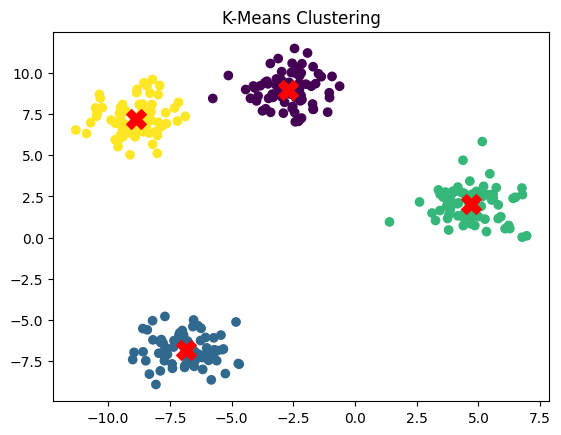

In [1]:
# 21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Generate data
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            color='red', marker='X', s=200)

plt.title("K-Means Clustering")
plt.show()

In [2]:
# 22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels.
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

# Load dataset
iris = load_iris()
X = iris.data

# Apply Agglomerative Clustering
model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X)

print("First 10 Predicted Labels:")
print(labels[:10])

First 10 Predicted Labels:
[1 1 1 1 1 1 1 1 1 1]


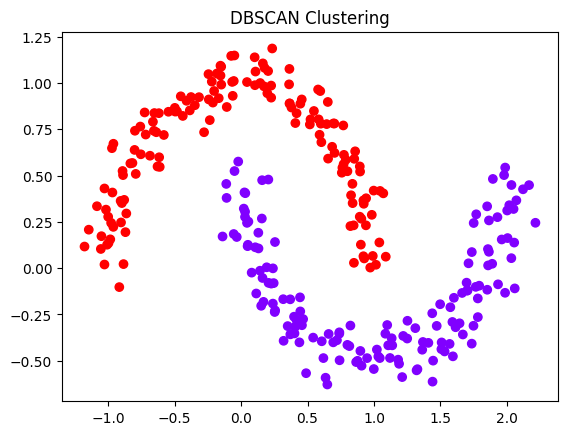

In [3]:
# 23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate data
X, y = make_moons(n_samples=300, noise=0.08, random_state=42)

# Apply DBSCAN
db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

# Plot clusters
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow')

# Highlight outliers
outliers = labels == -1
plt.scatter(X[outliers,0], X[outliers,1],
            color='black', marker='x', s=80)

plt.title("DBSCAN Clustering")
plt.show()

In [4]:
# 24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster.
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Load dataset
wine = load_wine()
X = wine.data

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Cluster sizes
unique, counts = np.unique(labels, return_counts=True)

print("Cluster Sizes:")
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")

Cluster Sizes:
Cluster 0: 65
Cluster 1: 51
Cluster 2: 62


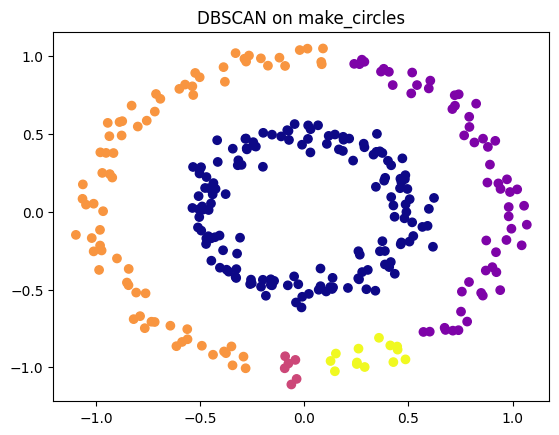

In [5]:
# 25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result.
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate data
X, y = make_circles(n_samples=300,
                    factor=0.5,
                    noise=0.05,
                    random_state=42)

# Apply DBSCAN
db = DBSCAN(eps=0.15, min_samples=5)
labels = db.fit_predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels, cmap='plasma')
plt.title("DBSCAN on make_circles")
plt.show()

In [6]:
# 26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids.
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Load dataset
data = load_breast_cancer()
X = data.data

# Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

print("Cluster Centroids:")
print(kmeans.cluster_centers_)

Cluster Centroids:
[[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


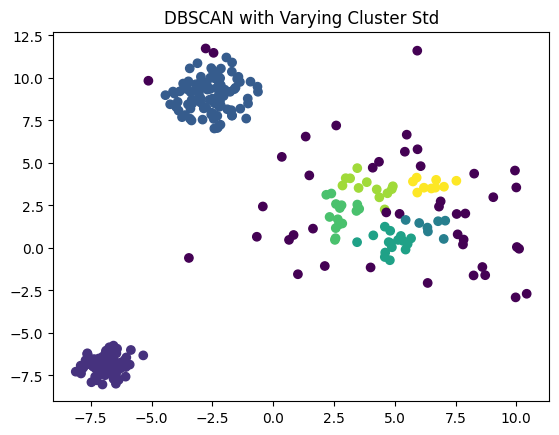

In [7]:
# 27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN.
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate data
X, y = make_blobs(n_samples=300,
                  centers=3,
                  cluster_std=[1.0, 2.5, 0.5],
                  random_state=42)

# Apply DBSCAN
db = DBSCAN(eps=0.8, min_samples=5)
labels = db.fit_predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.title("DBSCAN with Varying Cluster Std")
plt.show()

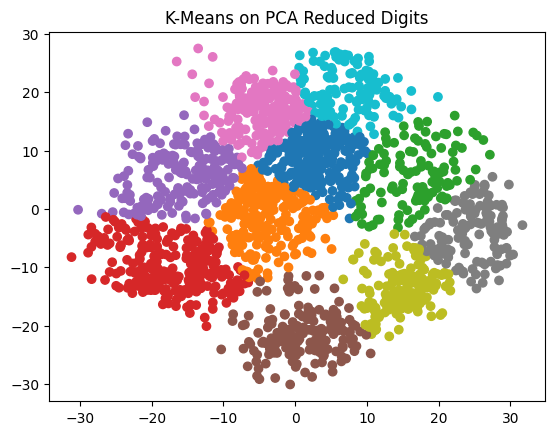

In [8]:
# 28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
digits = load_digits()
X = digits.data

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Plot
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10')
plt.title("K-Means on PCA Reduced Digits")
plt.show()

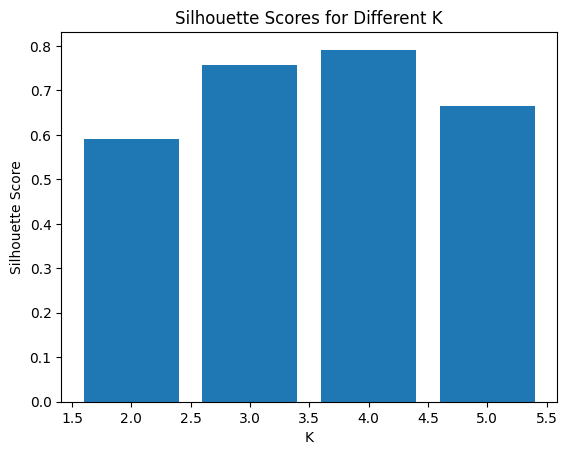

In [9]:
# 29. Create synthetic data using make_blobs and evaluate Silhouette Scores for K = 2 to 5. Display as a bar chart.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Generate data
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

scores = []
k_values = [2, 3, 4, 5]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

# Bar Chart
plt.bar(k_values, scores)
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different K")
plt.show()

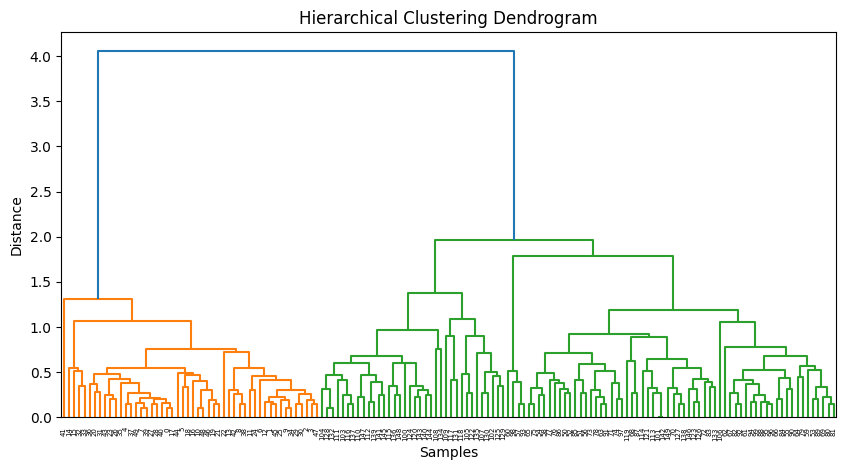

In [10]:
# 30. Load the Iris dataset and use Hierarchical Clustering to group data. Plot a dendrogram with average linkage.
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data

# Average Linkage
linked = linkage(X, method='average')

# Plot dendrogram
plt.figure(figsize=(10,5))
dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()